In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'])
print("Data loaded:", df.shape)


Data loaded: (9994, 21)


In [2]:
# Tanggal referensi = hari setelah transaksi terakhir
reference_date = df['Order Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency   = ('Order Date', lambda x: (reference_date - x.max()).days),
    Frequency = ('Order ID', 'nunique'),
    Monetary  = ('Sales', 'sum')
).reset_index()

print(rfm.head(10))
print("\nStatistik RFM:")
print(rfm.describe())

  Customer ID  Recency  Frequency   Monetary
0    AA-10315      185          5   5563.560
1    AA-10375       20          9   1056.390
2    AA-10480      260          4   1790.512
3    AA-10645       56          6   5086.935
4    AB-10015      416          3    886.156
5    AB-10060       55          8   7755.620
6    AB-10105       42         10  14473.571
7    AB-10150       42          5    966.710
8    AB-10165       26          8   1113.838
9    AB-10255      167          9    914.532

Statistik RFM:
           Recency   Frequency      Monetary
count   793.000000  793.000000    793.000000
mean    147.802018    6.316520   2896.848500
std     186.211051    2.550885   2628.670117
min       1.000000    1.000000      4.833000
25%      31.000000    5.000000   1146.050000
50%      76.000000    6.000000   2256.394000
75%     184.000000    8.000000   3785.276000
max    1166.000000   17.000000  25043.050000


In [3]:
# Bagi jadi 4 kuartil untuk tiap dimensi
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  q=4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
print(rfm[['Customer ID','Recency','Frequency','Monetary','RFM_Score']].head(10))

  Customer ID  Recency  Frequency   Monetary RFM_Score
0    AA-10315      185          5   5563.560       114
1    AA-10375       20          9   1056.390       441
2    AA-10480      260          4   1790.512       112
3    AA-10645       56          6   5086.935       324
4    AB-10015      416          3    886.156       111
5    AB-10060       55          8   7755.620       334
6    AB-10105       42         10  14473.571       344
7    AB-10150       42          5    966.710       311
8    AB-10165       26          8   1113.838       431
9    AB-10255      167          9    914.532       241


In [4]:
# Klasifikasi segment berdasarkan total score
rfm['Total_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

def segmentasi(score):
    if score >= 10:
        return 'Champions'
    elif score >= 8:
        return 'Loyal Customers'
    elif score >= 6:
        return 'Potential Loyalist'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm['Segment'] = rfm['Total_Score'].apply(segmentasi)

# Hitung jumlah per segment
segment_count = rfm['Segment'].value_counts().reset_index()
segment_count.columns = ['Segment', 'Jumlah']
print(segment_count)

              Segment  Jumlah
0     Loyal Customers     222
1           Champions     193
2  Potential Loyalist     182
3             At Risk     141
4      Lost Customers      55


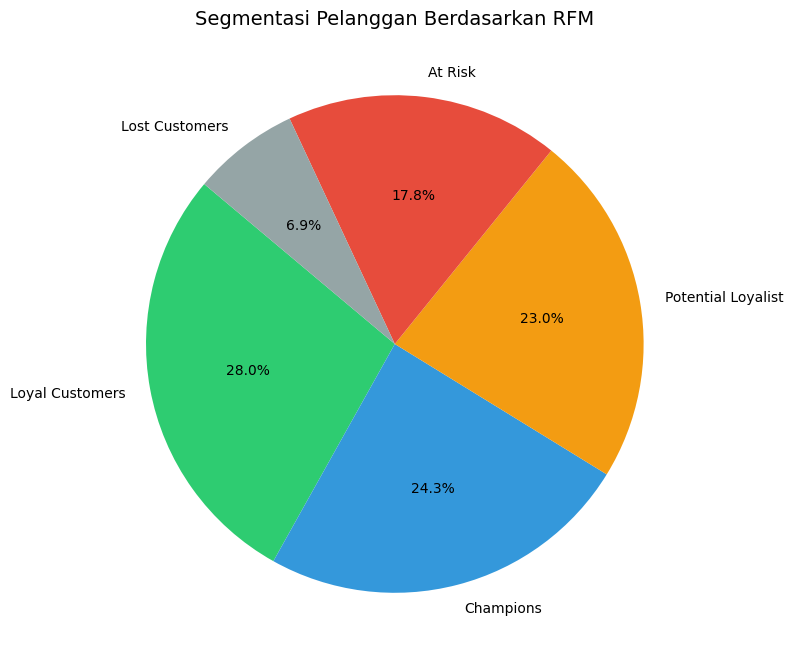

✅ File hasil_rfm.csv berhasil disimpan!


In [5]:
colors = ['#2ecc71','#3498db','#f39c12','#e74c3c','#95a5a6']

plt.figure(figsize=(8, 8))
plt.pie(segment_count['Jumlah'], 
        labels=segment_count['Segment'], 
        autopct='%1.1f%%', 
        colors=colors,
        startangle=140)
plt.title('Segmentasi Pelanggan Berdasarkan RFM', fontsize=14)
plt.tight_layout()
plt.show()

# Simpan hasil
rfm.to_csv('hasil_rfm.csv', index=False)
print(" File hasil_rfm.csv berhasil disimpan!")